# Survival Probability and Integer-Order Moments

This notebook illustrates **Sections 4–6 of the paper** and the package's main semi-analytic engine. It focuses on:

1. survival and liquidation probabilities across health buffers;
2. conditional moments through integer order \(k=4\);
3. the admissibility condition \(k\eta_{2,+}<1\).

The central package function is `h0_liquidation_moment_report`.

## 1. Setup and moment admissibility

In [1]:
from pathlib import Path
import sys

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "optimal_long_short").exists() and (path / "results").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False})

from optimal_long_short.job_runners.common import load_calibrated_params
from optimal_long_short.risk_report import h0_liquidation_moment_report

params, constraint = load_calibrated_params(ROOT / "results" / "params_WBTC_WETH.json")
T = 1.0 / 12.0
admissible_orders = [k for k in range(1, 101) if k * params.eta2_pos < 1.0]

pd.Series({
    "eta2_pos": params.eta2_pos,
    "largest admissible integer k (within 1..100)": max(admissible_orders),
    "k=4 admissibility margin": 1 - 4 * params.eta2_pos,
}).to_frame("value")

,value
eta2_pos,0.012494
largest admissible integer k (within 1..100),80.000000
k=4 admissibility margin,0.950024


## 2. Run one semi-analytic moment calculation

For a single strategy, use `ConditionalMoments`. Its methods return ordinary Python floats, which can be collected into a dictionary or DataFrame before plotting.

In [2]:
from optimal_long_short.market_params import MarketParams
from optimal_long_short.moments import ConditionalMoments
from optimal_long_short.strategy import UnitExposureLongShortStrategy

market = MarketParams(b=constraint["b"], S10=constraint["S10"], S20=constraint["S20"])
strategy = UnitExposureLongShortStrategy(h0=np.log(1.25), market=market, T=T)
moments = ConditionalMoments(params=params, strategy=strategy)

# Particular package calls and their scalar results.
one_point = {
    "p_surv()": moments.p_surv(),
    "conditional_moment(1)": moments.conditional_moment(1),
    "conditional_moment(2)": moments.conditional_moment(2),
    "conditional_moment(3)": moments.conditional_moment(3),
    "conditional_moment(4)": moments.conditional_moment(4),
    "conditional_variance()": moments.conditional_variance(),
}
pd.Series(one_point).to_frame("result").style.format(precision=6)

,result
p_surv(),0.868770
conditional_moment(1),0.997676
conditional_moment(2),1.051366
conditional_moment(3),1.169040
conditional_moment(4),1.369448
conditional_variance(),0.056009


For a grid, `h0_liquidation_moment_report` packages the repeated calls and returns a list of row dictionaries that converts directly to a DataFrame.

## 3. Compute survival and conditional moments

Each row below uses the same Laplace-resolvent architecture. Increasing \(k\) changes the tilt and forcing polynomial, but not the generic \(3	imes3\) barrier system.

In [3]:
H0_grid = np.array([constraint["H0_min"] + 0.002, 1.10, 1.20, 1.35, 1.50, 1.75, 2.00, 2.50])
report = pd.DataFrame(h0_liquidation_moment_report(
    params,
    np.log(H0_grid),
    b=constraint["b"],
    T=T,
    S10=constraint["S10"],
    S20=constraint["S20"],
    max_moment_order=4,
))
summary_cols = ["H0", "initial_leverage", "p_surv", "p_liq", "conditional_mean", "conditional_variance", "conditional_skewness", "conditional_excess_kurtosis"]
report[summary_cols].style.format(precision=5)

,H0,initial_leverage,p_surv,p_liq,conditional_mean,conditional_variance,conditional_skewness,conditional_excess_kurtosis
0,1.07049,3.68509,0.31497,0.68503,1.25126,0.07467,0.87563,1.09528
1,1.10000,3.43750,0.44032,0.55968,1.17462,0.06810,0.85679,1.02359
2,1.20000,2.85714,0.77166,0.22834,1.02989,0.05836,0.72277,0.64326
3,1.35000,2.36842,0.96318,0.03682,0.97284,0.05119,0.45906,0.26441
4,1.50000,2.08333,0.99588,0.00412,0.97474,0.04242,0.32608,0.28434
5,1.75000,1.80412,0.99993,0.00007,0.99024,0.03134,0.32754,0.38059
6,2.00000,1.63934,1.00000,0.00000,1.00069,0.02544,0.36576,0.40360
7,2.50000,1.45349,1.00000,0.00000,1.01253,0.01989,0.40690,0.42042


## 4. Survival and liquidation risk

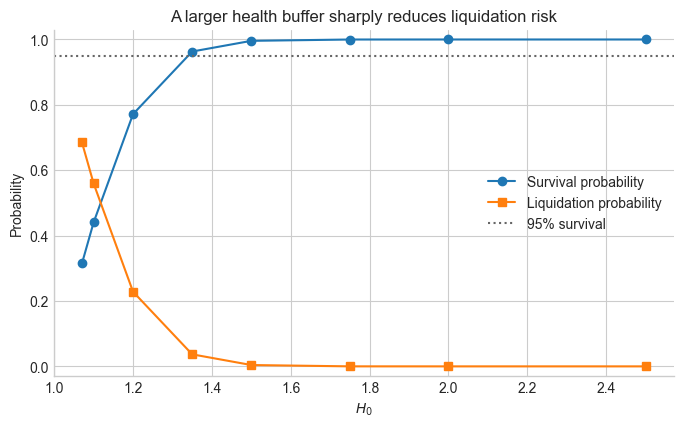

In [4]:
fig, ax = plt.subplots()
ax.plot(report["H0"], report["p_surv"], marker="o", label="Survival probability")
ax.plot(report["H0"], report["p_liq"], marker="s", label="Liquidation probability")
ax.axhline(0.95, color="0.4", ls=":", label="95% survival")
ax.set(xlabel="$H_0$", ylabel="Probability", ylim=(-0.03, 1.03), title="A larger health buffer sharply reduces liquidation risk")
ax.legend()
plt.show()

## 5. Higher-moment shape on surviving paths

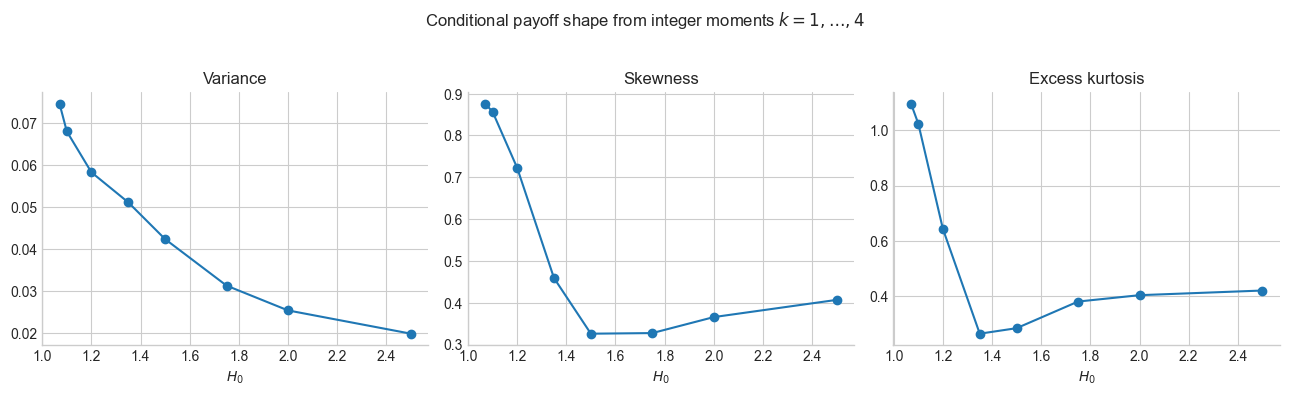

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, title in zip(
    axes,
    ["conditional_variance", "conditional_skewness", "conditional_excess_kurtosis"],
    ["Variance", "Skewness", "Excess kurtosis"],
):
    ax.plot(report["H0"], report[col], marker="o")
    ax.set(xlabel="$H_0$", title=title)
fig.suptitle(r"Conditional payoff shape from integer moments $k=1,\ldots,4$", y=1.03)
fig.tight_layout()
plt.show()

## 6. Compare the semi-analytic result with Monte Carlo

`MonteCarlo.run()` returns a `MonteCarloResult` containing terminal prices, survival flags, killed payoffs, and summary statistics. Here is a compact validation workflow.

In [6]:
from optimal_long_short.monte_carlo import MonteCarlo

mc_result = MonteCarlo(
    params=params,
    strategy=strategy,
    n_paths=20_000,
    n_steps=96,
    seed=42,
).run()

comparison = pd.DataFrame({
    "Laplace resolvent": [moments.p_surv(), moments.conditional_mean(), moments.conditional_variance()],
    "Monte Carlo": [mc_result.p_surv, mc_result.conditional_mean, mc_result.conditional_variance],
}, index=["survival probability", "conditional mean", "conditional variance"])
comparison["difference"] = comparison["Laplace resolvent"] - comparison["Monte Carlo"]
comparison.style.format(precision=6)

,Laplace resolvent,Monte Carlo,difference
survival probability,0.868770,0.875550,-0.006780
conditional mean,0.997676,0.994142,0.003534
conditional variance,0.056009,0.055926,0.000083


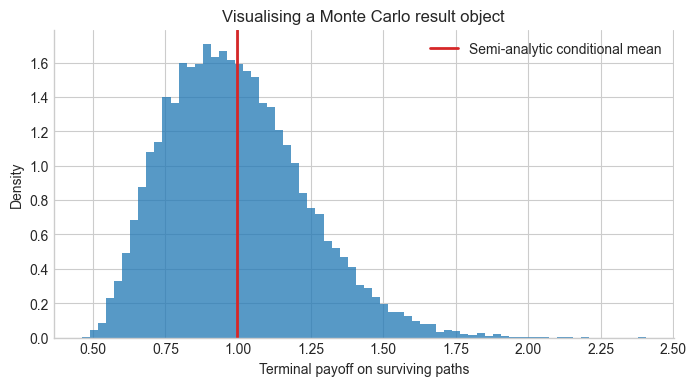

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mc_result.payoff[mc_result.survived], bins=70, density=True, alpha=0.75)
ax.axvline(moments.conditional_mean(), color="tab:red", lw=2, label="Semi-analytic conditional mean")
ax.set(xlabel="Terminal payoff on surviving paths", ylabel="Density", title="Visualising a Monte Carlo result object")
ax.legend()
plt.show()

## 7. Takeaway

The package exposes both barrier risk (`p_liq`) and the shape of the surviving-path payoff. This lets users move beyond mean–variance criteria without changing the core resolvent architecture.